# 3. Обучение модели Entity Resolution (GNN)

Пайплайн обучения GNN для поиска дубликатов строк между таблицами.

Процесс:
1. Загрузка конфига и данных из Pipeline 1 (ER пары таблиц)
2. Загрузка raw column embeddings из SM датасета (Pipeline 1) и проекция через SM модель (Pipeline 2)
3. Построение графов (FastText + projected column embeddings как edge_attr)
4. Обучение GNN (Triplet Loss + TransformerConv)
5. Визуальный анализ (t-SNE row embeddings)
6. Статистический анализ (loss, P/R/F1, пороговый анализ)

> **Важно:** Column embeddings **не генерируются заново** — используются raw embeddings
> из `sm_dataset.json` (Pipeline 1), которые проецируются через обученную SM ProjectionHead (Pipeline 2).
> Это исключает повторные вызовы LLM и Ollama Embedding API.

## 3.1 Загрузка конфигурации

In [1]:
import json
import os
import logging

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

CONFIG_PATH = 'config.json'

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    full_config = json.load(f)

data_gen_params = full_config['data_generation']
sm_params = full_config['schema_matching']
er_params = full_config['entity_resolution']

# Пути
ER_RAW_DIR = os.path.join(data_gen_params['output_dir'], data_gen_params['er_raw_dir'])
ER_GRAPHS_DIR = er_params['graphs_dir']
ER_MODEL_DIR = er_params['model_dir']
SM_MODEL_DIR = sm_params['model_dir']

print(f"ER raw данные: {ER_RAW_DIR}")
print(f"ER графы: {ER_GRAPHS_DIR}")
print(f"SM модель: {SM_MODEL_DIR}")
print(f"\nGNN: hidden_dim={er_params['hidden_dim']}, num_layers={er_params['num_gnn_layers']}, "
      f"heads={er_params['num_heads']}, output_dim={er_params['output_dim']}")
print(f"Обучение: epochs={er_params['num_epochs']}, lr={er_params['learning_rate']}, "
      f"margin={er_params['margin']}, mining={er_params['mining_strategy']}")

ER raw данные: unified_dataset\raw
ER графы: er_graphs
SM модель: sm_models

GNN: hidden_dim=256, num_layers=2, heads=4, output_dim=128
Обучение: epochs=500, lr=0.001, margin=0.3, mining=semihard


## 3.2 Загрузка ER пар и построение графов

In [2]:
from table_unifier.data_generation import DataGenConfig
from table_unifier.data_generation.columns import TablePairData
from table_unifier.entity_resolution.config import ERConfig
from table_unifier.entity_resolution.token_embedder import FastTextEmbedder
from table_unifier.entity_resolution.er_dataset import (
    build_and_save_graphs,
    load_and_project_column_cache,
)
from table_unifier.schema_matching.config import SMConfig
from table_unifier.schema_matching.inference import SchemaMatcherInference

# Путь к SM датасету (raw embeddings из Pipeline 1)
SM_DATASET_PATH = os.path.join(data_gen_params['output_dir'], data_gen_params['sm_dataset_file'])

# Загружаем ER пары из CSV + table_ids из meta
def load_er_pairs_from_dir(raw_dir: str, split: str):
    """Загрузить пары таблиц из CSV + meta.json.
    
    Returns:
        (pairs, table_ids): список пар и список (table_id_a, table_id_b)
    """
    split_dir = os.path.join(raw_dir, split)
    if not os.path.exists(split_dir):
        return [], []

    pairs = []
    table_ids = []
    meta_files = sorted(Path(split_dir).glob('*_meta.json'))
    for meta_file in meta_files:
        prefix = meta_file.stem.replace('_meta', '')

        with open(meta_file, 'r', encoding='utf-8') as f:
            meta = json.load(f)

        df_a = pd.read_csv(os.path.join(split_dir, f'{prefix}_table_a.csv'))
        df_b = pd.read_csv(os.path.join(split_dir, f'{prefix}_table_b.csv'))

        pair = TablePairData(
            df_a=df_a,
            df_b=df_b,
            duplicate_pairs=[tuple(p) for p in meta['duplicate_pairs']],
            column_mapping_a=meta['column_mapping_a'],
            column_mapping_b=meta['column_mapping_b'],
            entity_ids_a=meta['entity_ids_a'],
            entity_ids_b=meta['entity_ids_b'],
        )
        pairs.append(pair)
        table_ids.append((meta.get('table_id_a', -1), meta.get('table_id_b', -1)))

    return pairs, table_ids

train_pairs, train_tids = load_er_pairs_from_dir(ER_RAW_DIR, 'train')
val_pairs, val_tids = load_er_pairs_from_dir(ER_RAW_DIR, 'val')
test_pairs, test_tids = load_er_pairs_from_dir(ER_RAW_DIR, 'test')

print(f"Пар загружено: train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}")
print(f"SM датасет: {SM_DATASET_PATH}")

Пар загружено: train=300, val=50, test=50
SM датасет: unified_dataset\sm_dataset.json


In [3]:
# Создаём ERConfig
er_config = ERConfig(
    # Ollama
    ollama_host=data_gen_params['ollama_host'],
    embedding_model=data_gen_params['embedding_model'],
    llm_model=data_gen_params['llm_model'],
    # FastText
    fasttext_model_path=er_params['fasttext_model_path'],
    token_embed_dim=er_params['token_embed_dim'],
    # Graph
    min_token_length=er_params['min_token_length'],
    max_token_length=er_params['max_token_length'],
    max_token_doc_freq=er_params['max_token_doc_freq'],
    cell_separator=er_params['cell_separator'],
    # GNN
    hidden_dim=er_params['hidden_dim'],
    edge_dim=er_params['edge_dim'],
    num_gnn_layers=er_params['num_gnn_layers'],
    num_heads=er_params['num_heads'],
    dropout=er_params['dropout'],
    use_jumping_knowledge=er_params['use_jumping_knowledge'],
    output_dim=er_params['output_dim'],
    # Training
    batch_size=er_params['batch_size'],
    learning_rate=er_params['learning_rate'],
    weight_decay=er_params['weight_decay'],
    num_epochs=er_params['num_epochs'],
    margin=er_params['margin'],
    mining_strategy=er_params['mining_strategy'],
    scheduler_patience=er_params['scheduler_patience'],
    early_stopping_patience=er_params['early_stopping_patience'],
    # Paths
    graphs_dir=er_params['graphs_dir'],
)

print(f"ERConfig создан")

ERConfig создан


In [4]:
# Загрузка FastText
print(f"Загрузка FastText модели: {er_config.fasttext_model_path}")
ft_embedder = FastTextEmbedder(er_config.fasttext_model_path)
print(f"FastText dim: {ft_embedder.dim}")

# Загрузка SM модели (только для проекции, без Ollama вызовов)
sm_config = SMConfig(
    ollama_host=data_gen_params['ollama_host'],
    embedding_model=data_gen_params['embedding_model'],
    llm_model=data_gen_params['llm_model'],
)
sm_model_path = os.path.join(SM_MODEL_DIR, 'best_model.pt')
sm_inference = SchemaMatcherInference(model_path=sm_model_path, config=sm_config)
print(f"SM модель загружена из {sm_model_path}")

# Размерность column embeddings = выход SM проекции (triplet loss)
col_embed_dim = sm_params['output_dim']
print(f"Column embedding dim: {col_embed_dim}")

# Построение col_cache из SM датасета (Pipeline 1) — без LLM и Ollama!
# Raw embeddings уже вычислены в Pipeline 1, здесь только проекция через SM
all_pairs = train_pairs + val_pairs + test_pairs
all_tids = train_tids + val_tids + test_tids
col_cache = load_and_project_column_cache(
    pairs=all_pairs,
    pair_table_ids=all_tids,
    sm_dataset_path=SM_DATASET_PATH,
    sm_inference=sm_inference,
)
print(f"Column cache: {len(col_cache)} уникальных столбцов (raw → SM projection)")

2026-03-06 12:30:59,240 [INFO] Загрузка FastText модели из ../cc.ru.300.bin...
2026-03-06 12:30:59,282 [INFO] loading 2000000 words for fastText model from ..\cc.ru.300.bin


Загрузка FastText модели: ../cc.ru.300.bin


2026-03-06 12:31:03,200 [INFO] FastText lifecycle event {'params': 'FastText<vocab=0, vector_size=300, alpha=0.025>', 'datetime': '2026-03-06T12:31:03.200831', 'gensim': '4.4.0', 'python': '3.12.11 (main, Aug 18 2025, 19:17:54) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'created'}
2026-03-06 12:31:03,201 [INFO] Updating model with new vocabulary
2026-03-06 12:31:06,979 [INFO] FastText lifecycle event {'msg': 'added 2000000 new unique words (100.00% of original 2000000) and increased the count of 0 pre-existing words (0.00% of original 2000000)', 'datetime': '2026-03-06T12:31:06.979420', 'gensim': '4.4.0', 'python': '3.12.11 (main, Aug 18 2025, 19:17:54) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-03-06 12:31:10,740 [INFO] deleting the raw counts dictionary of 2000000 items
2026-03-06 12:31:10,742 [INFO] sample=1e-05 downsamples 3170 most-common words
2026-03-06 12:31:10,742 [INFO] FastText li

FastText dim: 300


2026-03-06 12:31:37,327 [INFO] SchemaMatcherInference: model=sm_models\best_model.pt, device=cuda


SM модель загружена из sm_models\best_model.pt
Column embedding dim: 256


2026-03-06 12:31:46,878 [INFO] SM датасет загружен: 12288 записей
2026-03-06 12:31:46,880 [WARNING] Column 'Прримечание' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,882 [WARNING] Column 'NTES' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,886 [WARNING] Column 'Notes' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,888 [WARNING] Column 'Примечание' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,891 [WARNING] Column 'Additional Info' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,893 [WARNING] Column 'Remarks' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,895 [WARNING] Column 'Прим.' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,896 [WARNING] Column 'КОММНЕТАРИЙ' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,901 [WARNING] Column ' AdditionalInfo' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,903 [WARNING] Column 'Комментарй' (table_id=-1) не найден в SM датасете
2026-03-06 12:31:46,9

Column cache: 9604 уникальных столбцов (raw → SM projection)


In [5]:
# Построение и сохранение графов (col_cache уже готов — без LLM/Ollama)
for split, pairs in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    split_graph_dir = os.path.join(ER_GRAPHS_DIR, split)
    os.makedirs(split_graph_dir, exist_ok=True)

    print(f"\nПостроение графов: {split} ({len(pairs)} пар)")
    n_built = build_and_save_graphs(
        pairs=pairs,
        config=er_config,
        output_dir=split_graph_dir,
        sm_inference=sm_inference,
        fasttext_embedder=ft_embedder,
        skip_existing=True,
        col_cache=col_cache,
    )
    print(f"  Построено: {n_built} графов")

# Проверка
for split in ['train', 'val', 'test']:
    n_files = len(list(Path(os.path.join(ER_GRAPHS_DIR, split)).glob('*.pt')))
    print(f"{split}: {n_files} .pt файлов")

2026-03-06 12:31:48,211 [INFO] Пропущено 300 уже построенных графов
2026-03-06 12:31:48,212 [INFO] Все графы уже построены!
2026-03-06 12:31:48,213 [INFO] Пропущено 50 уже построенных графов
2026-03-06 12:31:48,213 [INFO] Все графы уже построены!
2026-03-06 12:31:48,214 [INFO] Пропущено 50 уже построенных графов
2026-03-06 12:31:48,214 [INFO] Все графы уже построены!



Построение графов: train (300 пар)
  Построено: 300 графов

Построение графов: val (50 пар)
  Построено: 50 графов

Построение графов: test (50 пар)
  Построено: 50 графов
train: 300 .pt файлов
val: 50 .pt файлов
test: 50 .pt файлов


## 3.3 Анализ графов

In [6]:
# Статистика по графам
from table_unifier.entity_resolution.er_dataset import ERGraphDataset

train_dataset = ERGraphDataset(os.path.join(ER_GRAPHS_DIR, 'train'))

graph_stats = []
for i in range(min(len(train_dataset), 50)):
    g = train_dataset[i]
    graph_stats.append({
        'num_row_nodes': g['row'].x.shape[0],
        'num_token_nodes': g['token'].x.shape[0],
        'num_edges': g['row', 'has_token', 'token'].edge_index.shape[1],
        'edge_attr_dim': g['row', 'has_token', 'token'].edge_attr.shape[1],
        'num_unique_entities': len(g['row'].entity_label.unique()),
    })

stats_df = pd.DataFrame(graph_stats)
print("Статистика по графам (первые 50):")
print(stats_df.describe().round(1))

2026-03-06 12:31:48,223 [INFO] ERGraphDataset: 300 графов из er_graphs\train


Статистика по графам (первые 50):
       num_row_nodes  num_token_nodes  num_edges  edge_attr_dim  \
count           50.0             50.0       50.0           50.0   
mean            70.4            547.8     1131.2          256.0   
std             12.3             90.8      240.9            0.0   
min             45.0            354.0      598.0          256.0   
25%             64.0            493.0     1023.5          256.0   
50%             70.5            551.0     1097.5          256.0   
75%             77.0            601.5     1301.0          256.0   
max             98.0            778.0     1655.0          256.0   

       num_unique_entities  
count                 50.0  
mean                  64.9  
std                   12.0  
min                   39.0  
25%                   58.2  
50%                   65.5  
75%                   73.5  
max                   91.0  


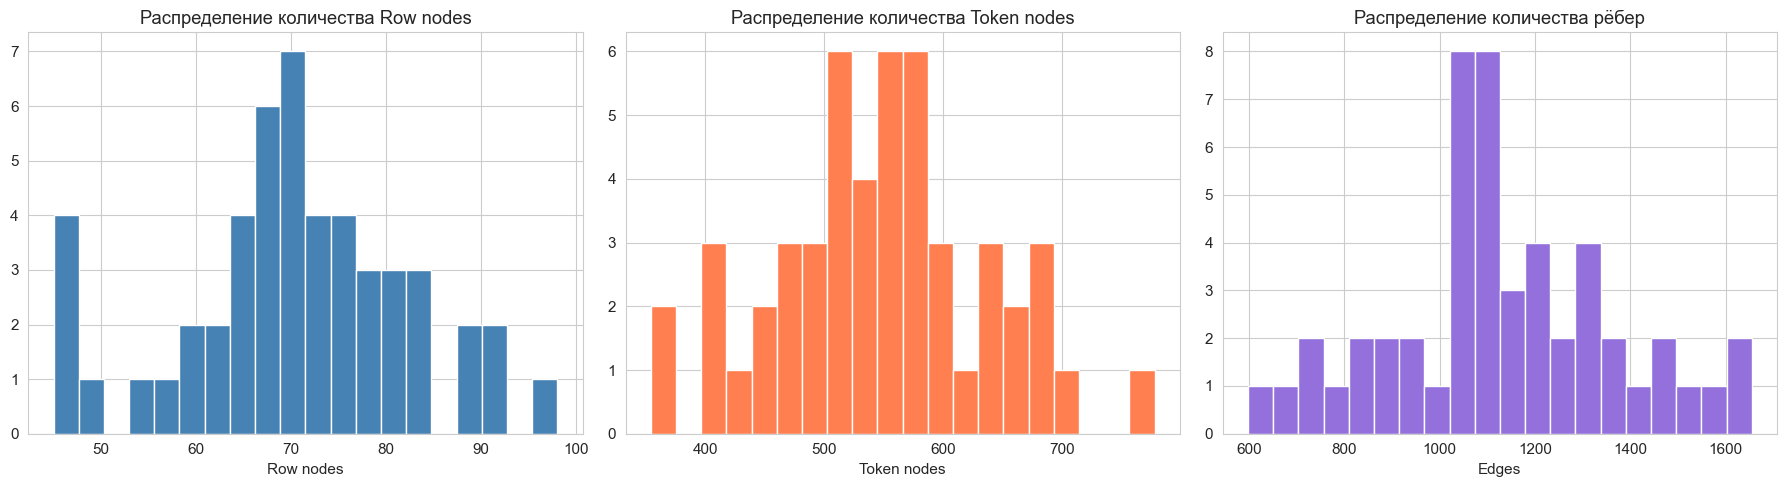

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(stats_df['num_row_nodes'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Row nodes')
axes[0].set_title('Распределение количества Row nodes')

axes[1].hist(stats_df['num_token_nodes'], bins=20, color='coral', edgecolor='white')
axes[1].set_xlabel('Token nodes')
axes[1].set_title('Распределение количества Token nodes')

axes[2].hist(stats_df['num_edges'], bins=20, color='mediumpurple', edgecolor='white')
axes[2].set_xlabel('Edges')
axes[2].set_title('Распределение количества рёбер')

plt.tight_layout()
plt.show()

## 3.4 Обучение GNN

In [8]:
from table_unifier.entity_resolution.trainer import ERTrainer

trainer = ERTrainer(
    config=er_config,
    row_input_dim=ft_embedder.dim,
    col_embed_dim=col_embed_dim,
)

print(f"Device: {trainer.device}")
num_params = sum(p.numel() for p in trainer.model.parameters())
print(f"Параметров модели: {num_params:,}")

2026-03-06 12:31:48,472 [INFO] ERTrainer: device=cuda
2026-03-06 12:31:48,514 [INFO] Модель: 1,669,376 параметров
2026-03-06 12:31:48,514 [INFO] Triplet mining strategy: semihard


Device: cuda
Параметров модели: 1,669,376


In [9]:
history = trainer.train(
    train_dir=os.path.join(ER_GRAPHS_DIR, 'train'),
    val_dir=os.path.join(ER_GRAPHS_DIR, 'val'),
    save_dir=ER_MODEL_DIR,
)

print(f"\nОбучение завершено. Модель сохранена в {ER_MODEL_DIR}/")

2026-03-06 12:31:48,521 [INFO] ERGraphDataset: 300 графов из er_graphs\train
2026-03-06 12:31:48,522 [INFO] ERGraphDataset: 50 графов из er_graphs\val
2026-03-06 12:31:48,523 [INFO] Train: 300 графов, Val: 50 графов
2026-03-06 12:31:48,523 [INFO] Batch size: 16, Epochs: 500
2026-03-06 12:31:57,213 [INFO] Epoch   1/500 | Train Loss: 0.1876 | Val Loss: 0.1844 | P/R/F1: 1.000/0.009/0.018 | LR: 1.00e-03 | Time: 8.7s
2026-03-06 12:31:57,246 [INFO]   -> Лучшая модель сохранена (val_loss=0.1844)
2026-03-06 12:32:05,847 [INFO] Epoch   2/500 | Train Loss: 0.1827 | Val Loss: 0.1842 | P/R/F1: 1.000/0.011/0.022 | LR: 1.00e-03 | Time: 8.6s
2026-03-06 12:32:05,878 [INFO]   -> Лучшая модель сохранена (val_loss=0.1842)
2026-03-06 12:32:14,371 [INFO] Epoch   3/500 | Train Loss: 0.1806 | Val Loss: 0.1855 | P/R/F1: 1.000/0.012/0.024 | LR: 1.00e-03 | Time: 8.5s
2026-03-06 12:32:23,002 [INFO] Epoch   4/500 | Train Loss: 0.1809 | Val Loss: 0.1789 | P/R/F1: 1.000/0.009/0.017 | LR: 1.00e-03 | Time: 8.6s
2026-


Обучение завершено. Модель сохранена в er_models/


## 3.5 Кривые обучения

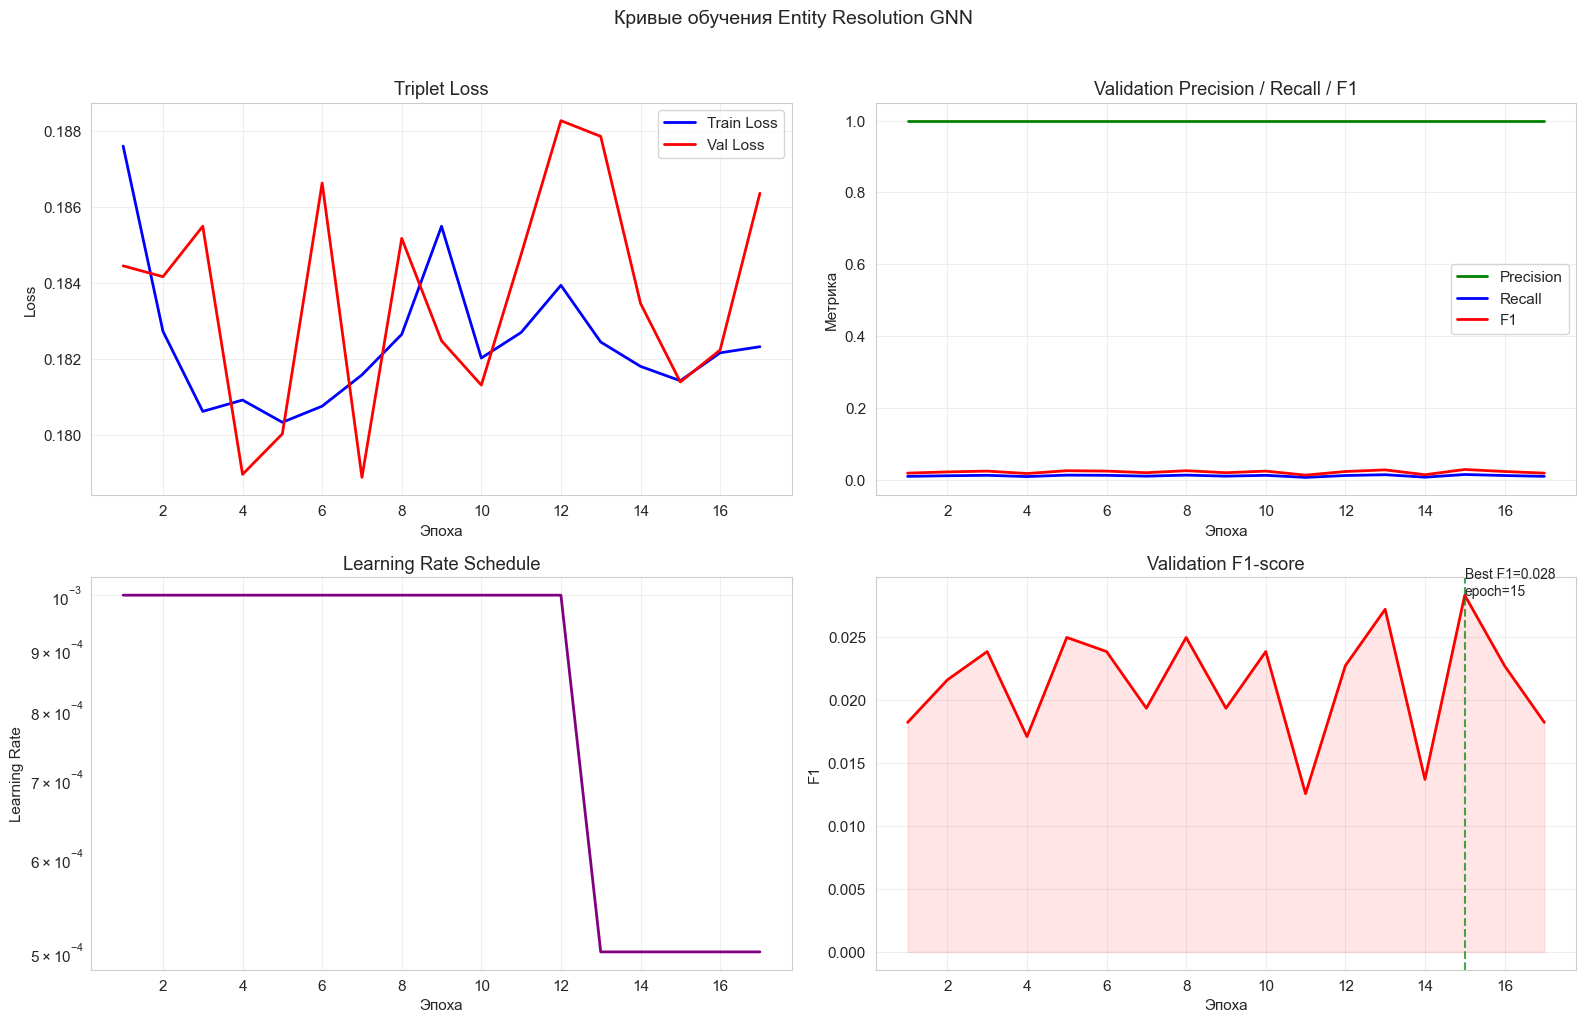

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Triplet Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Precision / Recall / F1
axes[0, 1].plot(epochs, history['val_precision'], 'g-', label='Precision', linewidth=2)
axes[0, 1].plot(epochs, history['val_recall'], 'b-', label='Recall', linewidth=2)
axes[0, 1].plot(epochs, history['val_f1'], 'r-', label='F1', linewidth=2)
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Метрика')
axes[0, 1].set_title('Validation Precision / Recall / F1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate
axes[1, 0].plot(epochs, history['learning_rate'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# F1 отдельно (крупно)
axes[1, 1].plot(epochs, history['val_f1'], 'r-', linewidth=2)
axes[1, 1].fill_between(epochs, 0, history['val_f1'], alpha=0.1, color='red')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('F1')
axes[1, 1].set_title('Validation F1-score')
axes[1, 1].grid(True, alpha=0.3)
if history['val_f1']:
    best_f1_epoch = np.argmax(history['val_f1']) + 1
    best_f1 = max(history['val_f1'])
    axes[1, 1].axvline(best_f1_epoch, color='green', linestyle='--', alpha=0.7)
    axes[1, 1].annotate(f'Best F1={best_f1:.3f}\nepoch={best_f1_epoch}',
                        xy=(best_f1_epoch, best_f1), fontsize=10)

plt.suptitle('Кривые обучения Entity Resolution GNN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.6 Оценка на тестовой выборке

In [11]:
from table_unifier.entity_resolution.inference import evaluate_on_test
from table_unifier.entity_resolution.gnn_model import EntityResolutionGNN

# Загружаем лучшую модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = EntityResolutionGNN(
    row_input_dim=ft_embedder.dim,
    col_embed_dim=col_embed_dim,
    config=er_config,
)
checkpoint = torch.load(
    os.path.join(ER_MODEL_DIR, 'best_model.pt'),
    map_location=device,
    weights_only=False,
)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.to(device)
best_model.eval()

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
test_metrics = evaluate_on_test(
    model=best_model,
    test_dir=os.path.join(ER_GRAPHS_DIR, 'test'),
    config=er_config,
    device=device,
    thresholds=thresholds,
)

print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

2026-03-06 12:34:14,395 [INFO] ERGraphDataset: 50 графов из er_graphs\test


РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
  avg_duplicate_similarity: 0.4874
  std_duplicate_similarity: 0.6166
  avg_non_duplicate_similarity: 0.0450
  std_non_duplicate_similarity: 0.7078
  separability: 0.4425
  precision@0.5: 0.0131
  recall@0.5: 0.0805
  f1@0.5: 0.0226
  precision@0.6: 0.0131
  recall@0.6: 0.0805
  f1@0.6: 0.0226
  precision@0.7: 0.0132
  recall@0.7: 0.0805
  f1@0.7: 0.0226
  precision@0.8: 0.0133
  recall@0.8: 0.0805
  f1@0.8: 0.0228
  precision@0.9: 0.0135
  recall@0.9: 0.0805
  f1@0.9: 0.0231


## 3.7 Визуализация row embeddings (t-SNE)

In [12]:
from table_unifier.entity_resolution.er_dataset import ERGraphDataset, er_collate_fn
from torch_geometric.loader import DataLoader as PyGDataLoader

# Собираем эмбеддинги из тестовых графов
test_dataset = ERGraphDataset(os.path.join(ER_GRAPHS_DIR, 'test'))

all_embeddings = []
all_labels = []
all_table_ids = []

best_model.eval()
with torch.no_grad():
    for i in range(min(len(test_dataset), 20)):
        graph = test_dataset[i].to(device)
        emb = best_model(graph)
        all_embeddings.append(emb.cpu().numpy())
        all_labels.append(graph['row'].entity_label.cpu().numpy())
        all_table_ids.append(graph['row'].table_id.cpu().numpy())

all_emb = np.concatenate(all_embeddings)
all_lab = np.concatenate(all_labels)
all_tid = np.concatenate(all_table_ids)

print(f"Собрано {len(all_emb)} row embeddings из {min(len(test_dataset), 20)} графов")

2026-03-06 12:34:18,888 [INFO] ERGraphDataset: 50 графов из er_graphs\test


Собрано 1443 row embeddings из 20 графов


C:\Users\olegk\AppData\Local\Temp\ipykernel_18516\9947228.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(dup_labels))


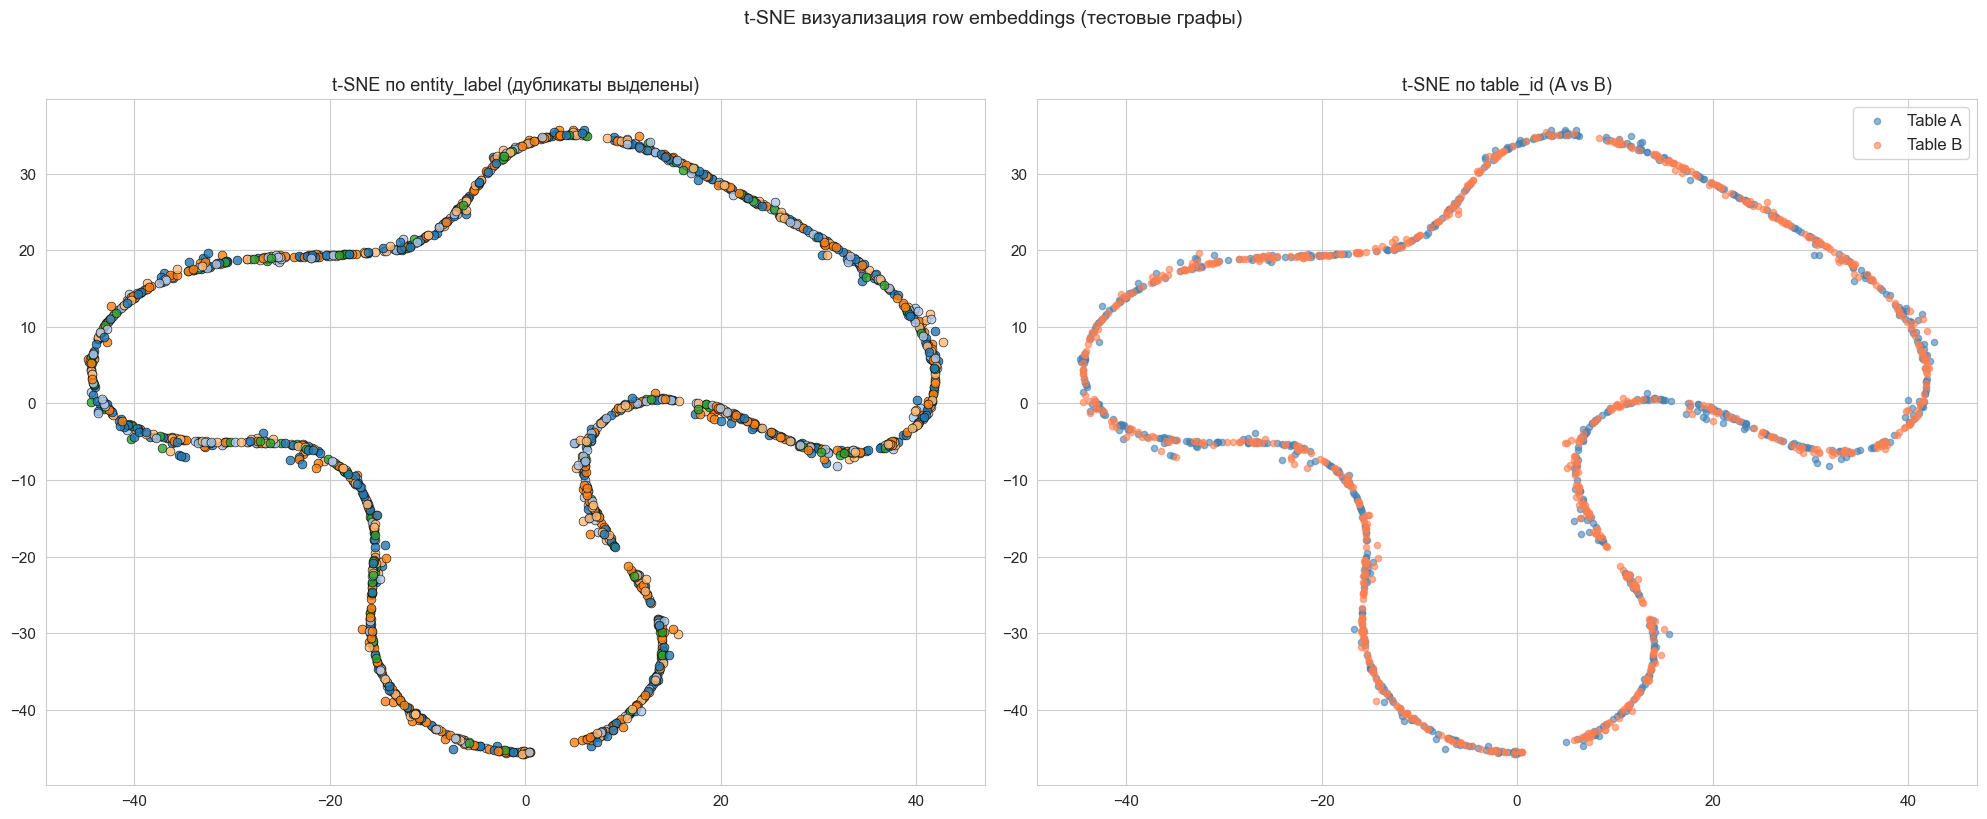

In [13]:
# t-SNE визуализация
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_emb) - 1), max_iter=1000)
tsne_result = tsne.fit_transform(all_emb)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# По entity_label: дубликаты имеют одинаковый цвет
# Показываем только метки с дубликатами (count > 1)
unique_labels, counts = np.unique(all_lab, return_counts=True)
dup_labels = set(unique_labels[counts > 1])

dup_mask = np.array([l in dup_labels for l in all_lab])
non_dup_mask = ~dup_mask

axes[0].scatter(tsne_result[non_dup_mask, 0], tsne_result[non_dup_mask, 1],
                c='lightgrey', alpha=0.3, s=15, label='Unique')

cmap = plt.cm.get_cmap('tab20', len(dup_labels))
for i, label in enumerate(sorted(dup_labels)):
    mask = all_lab == label
    axes[0].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=[cmap(i % 20)], s=40, alpha=0.8, edgecolors='black', linewidths=0.5)

axes[0].set_title('t-SNE по entity_label (дубликаты выделены)', fontsize=13)

# По table_id: строки таблицы A vs B
axes[1].scatter(tsne_result[all_tid == 0, 0], tsne_result[all_tid == 0, 1],
                c='steelblue', alpha=0.6, s=20, label='Table A')
axes[1].scatter(tsne_result[all_tid == 1, 0], tsne_result[all_tid == 1, 1],
                c='coral', alpha=0.6, s=20, label='Table B')
axes[1].set_title('t-SNE по table_id (A vs B)', fontsize=13)
axes[1].legend(fontsize=12)

plt.suptitle('t-SNE визуализация row embeddings (тестовые графы)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.8 Пороговый анализ

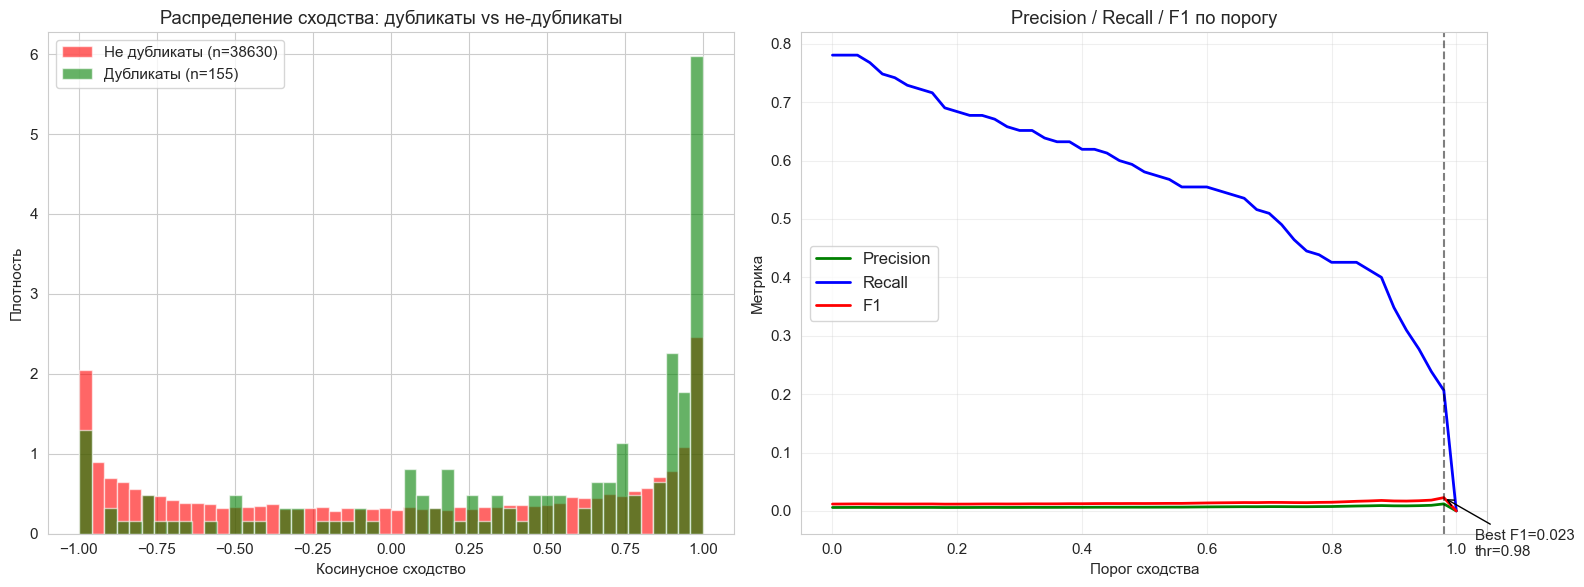

Оптимальный порог: 0.98 (F1=0.023)
Дубликаты: mean sim=0.4275, std=0.6323
Не дубликаты: mean sim=0.0412, std=0.7095


In [14]:
# Анализ распределения сходства между дубликатами и не-дубликатами
dup_sims = []
non_dup_sims = []

with torch.no_grad():
    for i in range(min(len(test_dataset), 30)):
        graph = test_dataset[i].to(device)
        emb = best_model(graph)
        labels = graph['row'].entity_label
        table_ids = graph['row'].table_id
        
        mask_a = table_ids == 0
        mask_b = table_ids == 1
        
        if mask_a.sum() == 0 or mask_b.sum() == 0:
            continue
        
        emb_a = emb[mask_a]
        emb_b = emb[mask_b]
        labels_a = labels[mask_a]
        labels_b = labels[mask_b]
        
        sim = torch.mm(emb_a, emb_b.t()).cpu().numpy()
        
        for ia in range(len(labels_a)):
            for ib in range(len(labels_b)):
                s = sim[ia, ib]
                if labels_a[ia] == labels_b[ib]:
                    dup_sims.append(s)
                else:
                    non_dup_sims.append(s)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Распределение сходств
axes[0].hist(non_dup_sims, bins=50, alpha=0.6, label=f'Не дубликаты (n={len(non_dup_sims)})',
             color='red', density=True)
axes[0].hist(dup_sims, bins=50, alpha=0.6, label=f'Дубликаты (n={len(dup_sims)})',
             color='green', density=True)
axes[0].set_xlabel('Косинусное сходство')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение сходства: дубликаты vs не-дубликаты')
axes[0].legend()

# P/R/F1 по порогам
thresholds_fine = np.arange(0.0, 1.01, 0.02)
precisions, recalls, f1s = [], [], []

for thr in thresholds_fine:
    tp = sum(1 for s in dup_sims if s >= thr)
    fp = sum(1 for s in non_dup_sims if s >= thr)
    fn = sum(1 for s in dup_sims if s < thr)
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    
    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

axes[1].plot(thresholds_fine, precisions, 'g-', label='Precision', linewidth=2)
axes[1].plot(thresholds_fine, recalls, 'b-', label='Recall', linewidth=2)
axes[1].plot(thresholds_fine, f1s, 'r-', label='F1', linewidth=2)
axes[1].set_xlabel('Порог сходства')
axes[1].set_ylabel('Метрика')
axes[1].set_title('Precision / Recall / F1 по порогу')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

best_thr_idx = np.argmax(f1s)
axes[1].axvline(thresholds_fine[best_thr_idx], color='black', linestyle='--', alpha=0.5)
axes[1].annotate(f'Best F1={f1s[best_thr_idx]:.3f}\nthr={thresholds_fine[best_thr_idx]:.2f}',
                 xy=(thresholds_fine[best_thr_idx], f1s[best_thr_idx]),
                 xytext=(thresholds_fine[best_thr_idx] + 0.05, f1s[best_thr_idx] - 0.1),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=11)

plt.tight_layout()
plt.show()

print(f"Оптимальный порог: {thresholds_fine[best_thr_idx]:.2f} (F1={f1s[best_thr_idx]:.3f})")
print(f"Дубликаты: mean sim={np.mean(dup_sims):.4f}, std={np.std(dup_sims):.4f}")
print(f"Не дубликаты: mean sim={np.mean(non_dup_sims):.4f}, std={np.std(non_dup_sims):.4f}")

In [15]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА ER")
print("=" * 60)
print(f"\nМодель: {ER_MODEL_DIR}/best_model.pt")
num_params = sum(p.numel() for p in best_model.parameters())
print(f"Параметров: {num_params:,}")
print(f"Архитектура: hidden={er_params['hidden_dim']}, layers={er_params['num_gnn_layers']}, "
      f"heads={er_params['num_heads']}, output={er_params['output_dim']}")
if history['val_f1']:
    print(f"Best val F1: {max(history['val_f1']):.4f}")
    print(f"Best val loss: {min(history['val_loss']):.4f}")
print(f"Оптимальный порог (тест): {thresholds_fine[best_thr_idx]:.2f}")
print(f"\nСледующий шаг: Pipeline 4 — Полный инференс SM + ER")

ИТОГОВАЯ СВОДКА ER

Модель: er_models/best_model.pt
Параметров: 1,669,376
Архитектура: hidden=256, layers=2, heads=4, output=128
Best val F1: 0.0283
Best val loss: 0.1789
Оптимальный порог (тест): 0.98

Следующий шаг: Pipeline 4 — Полный инференс SM + ER
